In [15]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import time
from pathlib import Path

Model Architecture - based on MobileNetV2  

Stage | Operator                  | t | c   | n | s | Output Size
------|---------------------------|---|-----|---|---|-------------
Input | Image                     | - | 3   | - | - | 224×224×3
Stem  | Conv 3×3                  | - | 32  | 1 | 2 | 112×112×32
1     | Bottleneck                | 1 | 16  | 1 | 1 | 112×112×16
2     | Bottleneck                | 6 | 24  | 2 | 2 | 56×56×24
3     | Bottleneck                | 6 | 32  | 3 | 2 | 28×28×32
4     | Bottleneck                | 6 | 64  | 4 | 2 | 14×14×64
5     | Bottleneck                | 6 | 96  | 3 | 1 | 14×14×96
6     | Bottleneck                | 6 | 160 | 3 | 2 | 7×7×160
7     | Bottleneck                | 6 | 320 | 1 | 1 | 7×7×320
Head  | Conv 1×1                  | - | 1280| 1 | 1 | 7×7×1280
Pool  | Global Avg Pool           | - | -   | - | - | 1×1×1280
FC    | Linear / Classifier       | - | -   | - | - | num_classes


In [18]:
# define transformations for training and val/test datasets

IMAGE_SIZE = 160  

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
# load data

data_dir = "data"

full_dataset = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=train_transforms
)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['with_mask', 'without_mask']
Total images: 7554


In [22]:
# apply tranformations + split into val/train/test 

g = torch.Generator().manual_seed(42)

train_frac, val_frac, test_frac = 0.8, 0.1, 0.1
n_total = len(full_dataset)
n_train = int(train_frac * n_total)
n_val   = int(val_frac * n_total)
n_test  = n_total - n_train - n_val  # handle rounding

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=g
)

print("Split sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

train_base = datasets.ImageFolder(root=data_dir, transform=train_transforms)
val_base = datasets.ImageFolder(root=data_dir, transform=val_test_transforms)
test_base = datasets.ImageFolder(root=data_dir, transform=val_test_transforms)

train_dataset = torch.utils.data.Subset(train_base, train_dataset.indices)
val_dataset   = torch.utils.data.Subset(val_base, val_dataset.indices)
test_dataset  = torch.utils.data.Subset(test_base, test_dataset.indices)


BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,   
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))
print("Batch images:", images.shape)   # [B, 3, 160, 160]
print("Batch labels:", labels.shape)   # [B]
print("First 10 labels:", labels[:10].tolist())

print("Class to index:", train_base.class_to_idx)

Split sizes: 6043 755 756
Batch images: torch.Size([32, 3, 160, 160])
Batch labels: torch.Size([32])
First 10 labels: [0, 0, 0, 1, 1, 0, 0, 0, 1, 0]
Class to index: {'with_mask': 0, 'without_mask': 1}


In [24]:
# define layer elements 

class ConvBNReLU(nn.Sequential):
    """
    Convenience block: Conv2d -> BatchNorm2d -> ReLU6
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        groups: int = 1,
    ):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU6(inplace=True),
        )

class InvertedResidual(nn.Module):
    """
    MobileNetV2 bottleneck (Inverted Residual with Linear Bottleneck)

    Structure:
      - 1x1 expansion conv (with ReLU6)
      - 3x3 depthwise conv (with ReLU6)
      - 1x1 projection conv (linear, no activation)
      - skip connection if stride==1 and in_channels==out_channels

    Args:
      in_channels:  input channels
      out_channels: output channels (c in the table)
      stride:       1 or 2 (s in the table)
      expand_ratio: expansion factor t (e.g., 1 or 6)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int,
        expand_ratio: int,
    ):
        super().__init__()
        
        hidden_dim = in_channels * expand_ratio
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

        layers = []

        if expand_ratio != 1:
            layers.append(ConvBNReLU(in_channels, hidden_dim, kernel_size=1, stride=1))

        layers.append(
            ConvBNReLU(hidden_dim, hidden_dim, kernel_size=3, stride=stride, groups=hidden_dim)
        )

        layers.append(
            nn.Sequential(
                nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.block(x)
        if self.use_res_connect:
            return x + out
        return out

In [26]:
# define forward pass

class MobileNetV2(nn.Module):
    """
    MobileNetV2 backbone + classifier head.

    Args:
      num_classes: number of output classes (2 for mask/no-mask)
      width_mult:  scale channels to make model smaller/faster (0.35, 0.5, 1.0)
      input_channels: usually 3 for RGB
    """
    def __init__(self, num_classes=2, width_mult=0.5, input_channels=3):
        super().__init__()

        # MobileNetV2 config: (t, c, n, s)
        cfg = [
            (1,  16, 1, 1),
            (6,  24, 2, 2),
            (6,  32, 3, 2),
            (6,  64, 4, 2),
            (6,  96, 3, 1),
            (6, 160, 3, 2),
            (6, 320, 1, 1),
        ]

        def _make_divisible(v, divisor=8, min_value=None):
            # Keep channels friendly for hardware (multiple of 8 is common)
            if min_value is None:
                min_value = divisor
            new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
            if new_v < 0.9 * v:
                new_v += divisor
            return new_v

        # Stem channels
        stem_channels = _make_divisible(32 * width_mult)
        last_channel  = _make_divisible(1280 * max(1.0, width_mult))

        layers = []
        # Stem: 3x3 conv stride 2
        layers.append(ConvBNReLU(input_channels, stem_channels, kernel_size=3, stride=2))
        in_channels = stem_channels

        # Bottleneck stages
        for t, c, n, s in cfg:
            out_channels = _make_divisible(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedResidual(in_channels, out_channels, stride=stride, expand_ratio=t))
                in_channels = out_channels

        # Head: 1x1 conv to last_channel
        layers.append(ConvBNReLU(in_channels, last_channel, kernel_size=1, stride=1))

        self.features = nn.Sequential(*layers)

        # Global average pooling + classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(last_channel, num_classes)

        # Optional: initialize weights (simple, good defaults)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)           
        x = self.avgpool(x)            
        x = torch.flatten(x, 1)        
        x = self.classifier(x)         
        return x

In [28]:
# define one backward pass

model = MobileNetV2()

device = torch.device("cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    # For precision/recall/F1 (binary)
    # We'll treat class "1" as the positive class by default.
    tp = fp = fn = tn = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # confusion matrix counts
        # positive = 1, negative = 0
        tp += ((preds == 1) & (labels == 1)).sum().item()
        fp += ((preds == 1) & (labels == 0)).sum().item()
        fn += ((preds == 0) & (labels == 1)).sum().item()
        tn += ((preds == 0) & (labels == 0)).sum().item()

    avg_loss = total_loss / max(1, total)
    acc = correct / max(1, total)

    precision = tp / max(1, (tp + fp))
    recall    = tp / max(1, (tp + fn))
    f1        = (2 * precision * recall) / max(1e-12, (precision + recall))

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn
    }
    
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return {
        "loss": total_loss / max(1, total),
        "acc": correct / max(1, total),
    }

In [132]:
EPOCHS = 10
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
best_path = ckpt_dir / "mobilenetv2_mask_best.pt"

best_val_f1 = -1.0

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_stats = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_stats = evaluate(model, val_loader, criterion, device)

    # Save best (by F1; you can also use val loss)
    if val_stats["f1"] > best_val_f1:
        best_val_f1 = val_stats["f1"]
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_stats": val_stats,
            },
            best_path,
        )

    dt = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_stats['loss']:.4f} train_acc={train_stats['acc']:.3f} | "
        f"val_loss={val_stats['loss']:.4f} val_acc={val_stats['acc']:.3f} "
        f"val_f1={val_stats['f1']:.3f} (P={val_stats['precision']:.3f}, R={val_stats['recall']:.3f}) | "
        f"{dt:.1f}s"
    )

total_dt = time.time() - start_time
print(f"Done. Best val F1: {best_val_f1:.3f}")
print("Best checkpoint saved to:", str(best_path))

Epoch 01/10 | train_loss=0.3853 train_acc=0.830 | val_loss=0.2586 val_acc=0.894 val_f1=0.884 (P=0.953, R=0.824) | 2035.5s
Epoch 02/10 | train_loss=0.2489 train_acc=0.896 | val_loss=0.1895 val_acc=0.918 val_f1=0.913 (P=0.950, R=0.878) | 501.6s
Epoch 03/10 | train_loss=0.1946 train_acc=0.923 | val_loss=0.1194 val_acc=0.954 val_f1=0.953 (P=0.949, R=0.957) | 512.3s
Epoch 04/10 | train_loss=0.1750 train_acc=0.929 | val_loss=0.1236 val_acc=0.958 val_f1=0.958 (P=0.931, R=0.986) | 488.9s
Epoch 05/10 | train_loss=0.1480 train_acc=0.944 | val_loss=0.1124 val_acc=0.956 val_f1=0.955 (P=0.962, R=0.949) | 527.8s
Epoch 06/10 | train_loss=0.1273 train_acc=0.953 | val_loss=0.1280 val_acc=0.958 val_f1=0.958 (P=0.940, R=0.976) | 510.3s
Epoch 07/10 | train_loss=0.1275 train_acc=0.954 | val_loss=0.1125 val_acc=0.963 val_f1=0.962 (P=0.978, R=0.946) | 821.7s
Epoch 08/10 | train_loss=0.1136 train_acc=0.956 | val_loss=0.0883 val_acc=0.972 val_f1=0.972 (P=0.960, R=0.984) | 1563.7s
Epoch 09/10 | train_loss=0.090

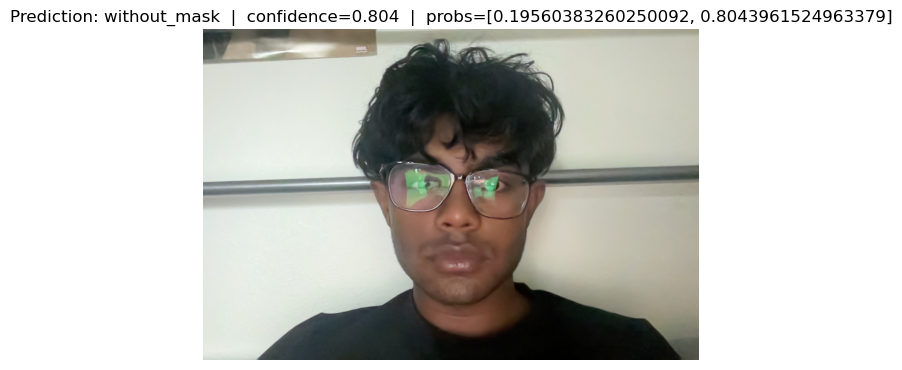

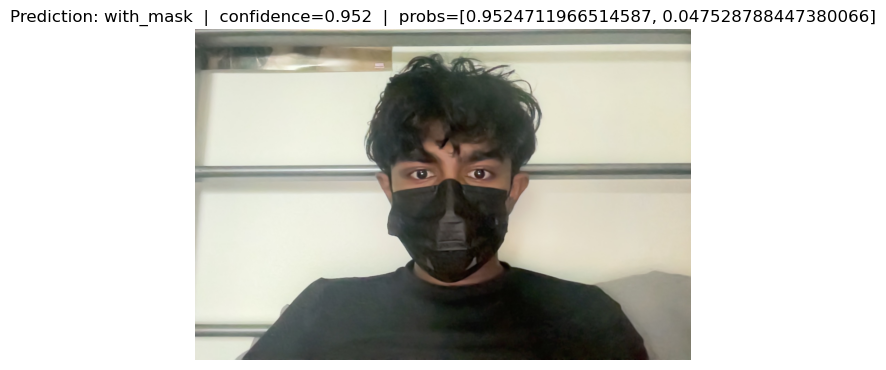

In [36]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path

DEVICE = torch.device("cpu")
CKPT_PATH = Path("checkpoints/mobilenetv2_mask_best.pt")
IMAGE_SIZE = 160

NUM_CLASSES = 2
WIDTH_MULT = 0.5  

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

model = MobileNetV2(num_classes=NUM_CLASSES, width_mult=WIDTH_MULT).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

idx_to_class = {0: "with_mask", 1: "without_mask"}

@torch.no_grad()
def predict_image(image_path: str):
    """Returns (pred_label_str, confidence_float, probs_list)."""
    img = Image.open(image_path).convert("RGB")
    x = val_test_transforms(img).unsqueeze(0).to(DEVICE)  # [1, 3, H, W]

    logits = model(x)                      # [1, 2]
    probs = torch.softmax(logits, dim=1)[0]  # [2]

    pred_idx = int(torch.argmax(probs).item())
    conf = float(probs[pred_idx].item())
    pred_label = idx_to_class[pred_idx]

    return pred_label, conf, probs.cpu().tolist()


def visualize_prediction(image_path: str):
    import matplotlib.pyplot as plt

    pred_label, conf, probs = predict_image(image_path)
    img = Image.open(image_path).convert("RGB")

    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_label}  |  confidence={conf:.3f}  |  probs={probs}")



visualize_prediction("test1.jpg")
visualize_prediction("test2.jpg")